### Problem Definition

- **Tujuan Bisnis:** Memprediksi risiko gagal bayar calon peminjam secara akurat untuk meminimalkan kredit macet (False Negative Rendah) sekaligus menjaga tingkat persetujuan nasabah potensial (False Positive Rendah) guna penyusunan personalisasi struktur pinjaman.
- **Tipe  ML:** Supervised Learning - Binary Classification (0 = Lancar, 1 = Gagal/Default).
- **Metrik Keberhasilan:**
    - Model: PR-AUC, Recall, F1-Score, ROC-AUC/Gini Coefficient.
    - Bisnis: Penurunan rasio NPL (Non-Performing Loan) dan Optimalisasi Approval Rate.

### Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('application_train.csv')

print('Dataset shape:', df.shape)
print('\nOverview 5 sampel data:')
df.head()

Dataset shape: (307511, 122)

Overview 5 sampel data:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### EDA Basic

In [3]:
print('Dataset info:')
df.info()

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [4]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct': df.isnull().mean() * 100
})
missing_analisis = (
    missing[missing['Missing Count'] > 0]
    .sort_values(by='Missing Pct', ascending=False)
)
print('Analisis missing value (Top 25):')
print(missing_analisis.head(25))

Analisis missing value (Top 25):
                          Missing Count  Missing Pct
COMMONAREA_MEDI                  214865    69.872297
COMMONAREA_MODE                  214865    69.872297
COMMONAREA_AVG                   214865    69.872297
NONLIVINGAPARTMENTS_MODE         213514    69.432963
NONLIVINGAPARTMENTS_MEDI         213514    69.432963
NONLIVINGAPARTMENTS_AVG          213514    69.432963
FONDKAPREMONT_MODE               210295    68.386172
LIVINGAPARTMENTS_AVG             210199    68.354953
LIVINGAPARTMENTS_MEDI            210199    68.354953
LIVINGAPARTMENTS_MODE            210199    68.354953
FLOORSMIN_MEDI                   208642    67.848630
FLOORSMIN_MODE                   208642    67.848630
FLOORSMIN_AVG                    208642    67.848630
YEARS_BUILD_MODE                 204488    66.497784
YEARS_BUILD_MEDI                 204488    66.497784
YEARS_BUILD_AVG                  204488    66.497784
OWN_CAR_AGE                      202929    65.990810
LANDAREA_AVG 

In [5]:
print('Jumlah data duplikat:', df.duplicated().sum())

print('\nStatistik deskriptif kolom numerik:')
df.describe()

Jumlah data duplikat: 0

Statistik deskriptif kolom numerik:


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [6]:
print('Statistik kolom kategorikal:')
df.select_dtypes(include='object').describe()

Statistik kolom kategorikal:


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,307511,307511,307511,307511,306219,307511,307511,307511,307511,211120,307511,307511,97216,153214,151170,161756
unique,2,3,2,2,7,8,5,6,6,18,7,58,4,3,7,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,278232,202448,202924,213312,248526,158774,218391,196432,272868,55186,53901,67992,73830,150503,66040,159428


In [7]:
print('Distribusi target:')
print(df['TARGET'].value_counts())

Distribusi target:
TARGET
0    282686
1     24825
Name: count, dtype: int64


### Data Cleaning

In [8]:
THRESHOLD = 60
missing_pct = df.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > THRESHOLD].index.tolist()
df = df.drop(columns=cols_to_drop)
print(f'Jumlah kolom missing > {THRESHOLD}% akan dihapus: {len(cols_to_drop)}')
print('Kolom yang dihapus:', cols_to_drop)

Jumlah kolom missing > 60% akan dihapus: 17
Kolom yang dihapus: ['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE']


In [9]:
# handling code gender
xna = (df['CODE_GENDER'] == 'XNA').sum()
df = df[df['CODE_GENDER'] != 'XNA']
print('Jumlah baris XNA yang dihapus:', xna)

# handling days employed
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'].abs() / 365
df = df.drop(columns=['DAYS_EMPLOYED'])

# handle format day birthday
df['AGE'] = df['DAYS_BIRTH'].abs() / 365
df = df.drop(columns=['DAYS_BIRTH'])

Jumlah baris XNA yang dihapus: 4


### Data Splitting

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=(15/85), random_state=RANDOM_STATE, stratify=y_train_temp
)

print('Train set shape:', X_train.shape, y_train.shape)
print('Val set shape:', X_val.shape, y_val.shape)
print('Test set shape:', X_test.shape, y_test.shape)

Train set shape: (215254, 103) (215254,)
Val set shape: (46126, 103) (46126,)
Test set shape: (46127, 103) (46127,)


### EDA Advance

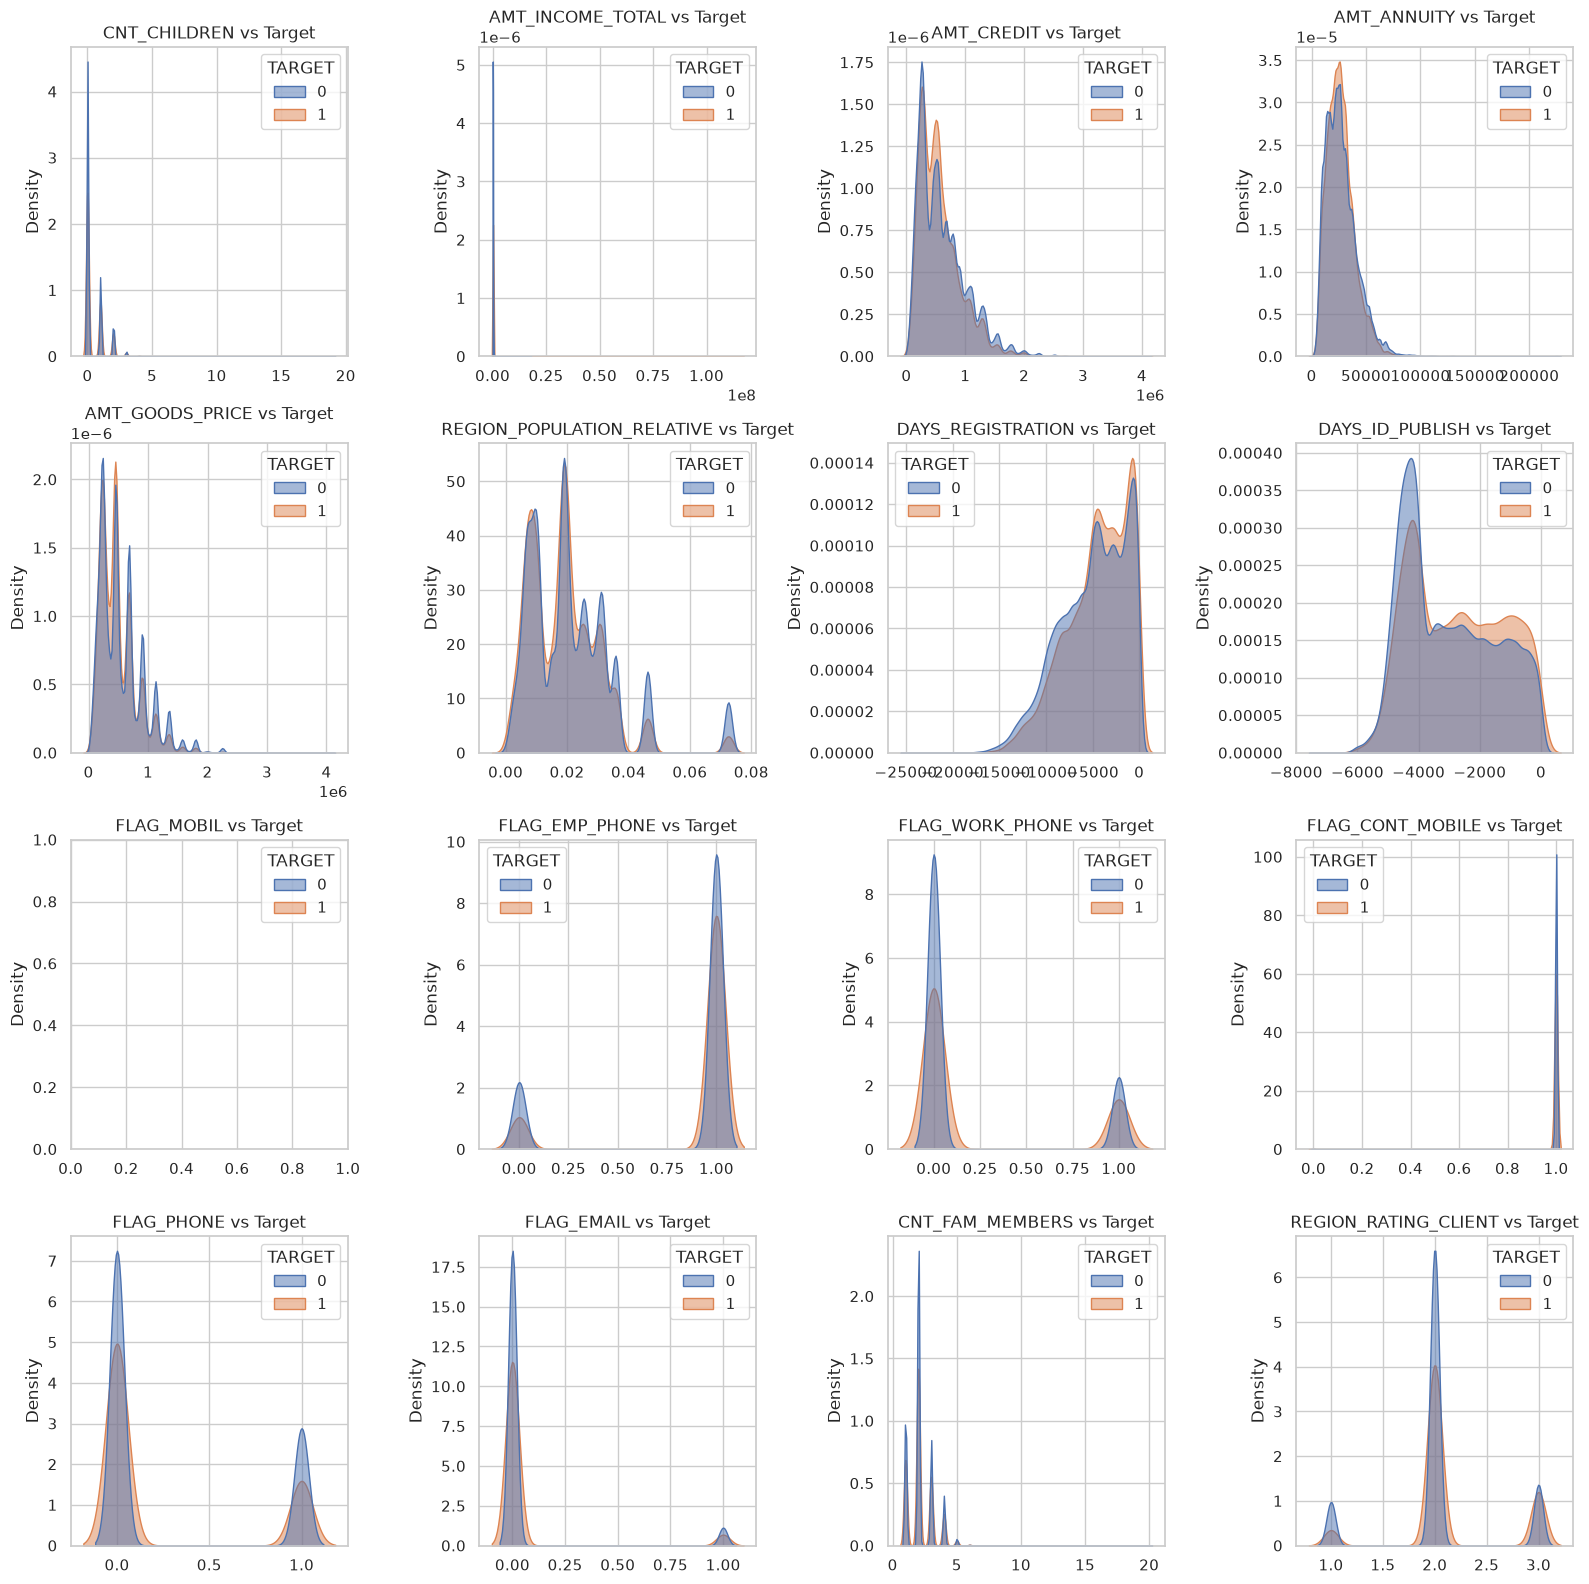

In [11]:
eda_df = X_train.copy()
eda_df['TARGET'] = y_train

# Distribusi numerik vs target
num_features = eda_df.select_dtypes(include=[np.number]).columns.drop('TARGET', errors='ignore')[:16]
n_cols = 4
n_rows = (len(num_features) + n_cols - 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))
for i, col in enumerate(num_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(
        data=eda_df, 
        x=col, 
        hue='TARGET', 
        common_norm=False, 
        fill=True, 
        alpha=0.5
    )
    plt.title(f'{col} vs Target', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

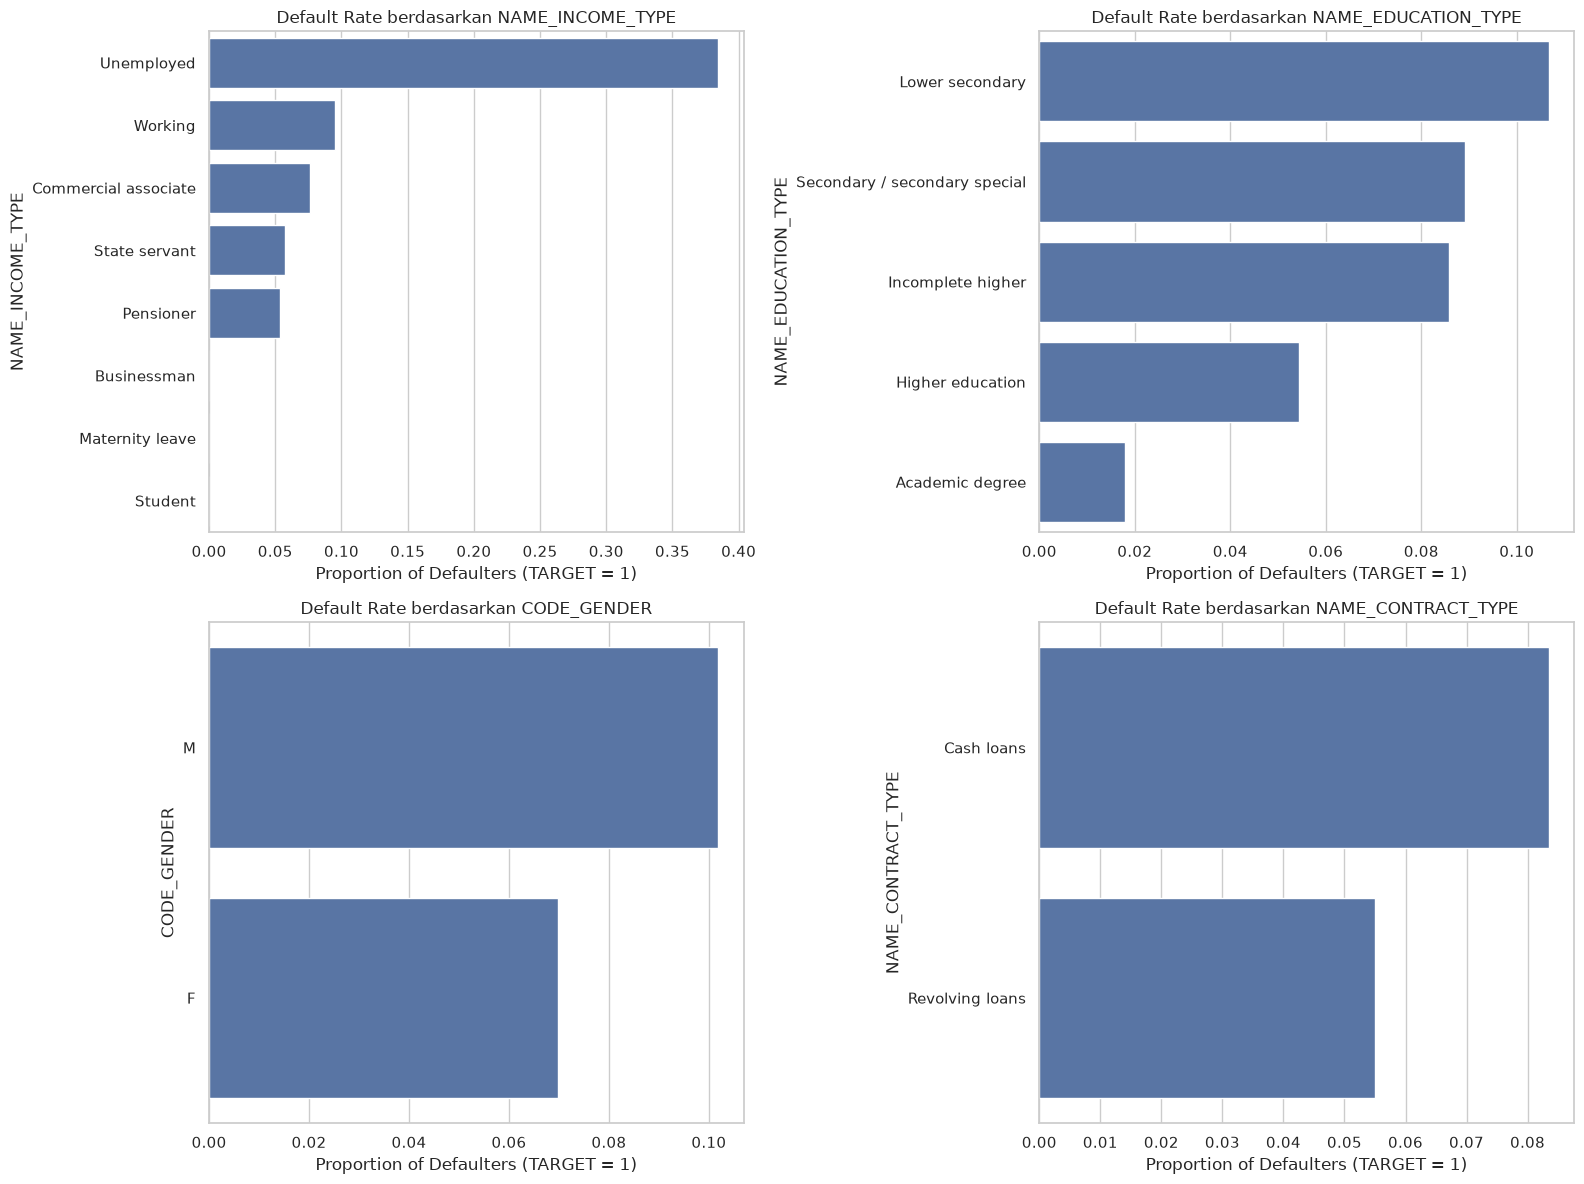

In [12]:
# Default rate profil kategorikal
cat_features = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'CODE_GENDER', 'NAME_CONTRACT_TYPE']

plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_features):
    plt.subplot(2, 2, i + 1)
    order_cat = eda_df.groupby(col)['TARGET'].mean().sort_values(ascending=False).index
    
    sns.barplot(data=eda_df, x='TARGET', y=col, order=order_cat, errorbar=None)
    plt.title(f'Default Rate berdasarkan {col}')
    plt.xlabel('Proportion of Defaulters (TARGET = 1)')
    
plt.tight_layout()
plt.show()

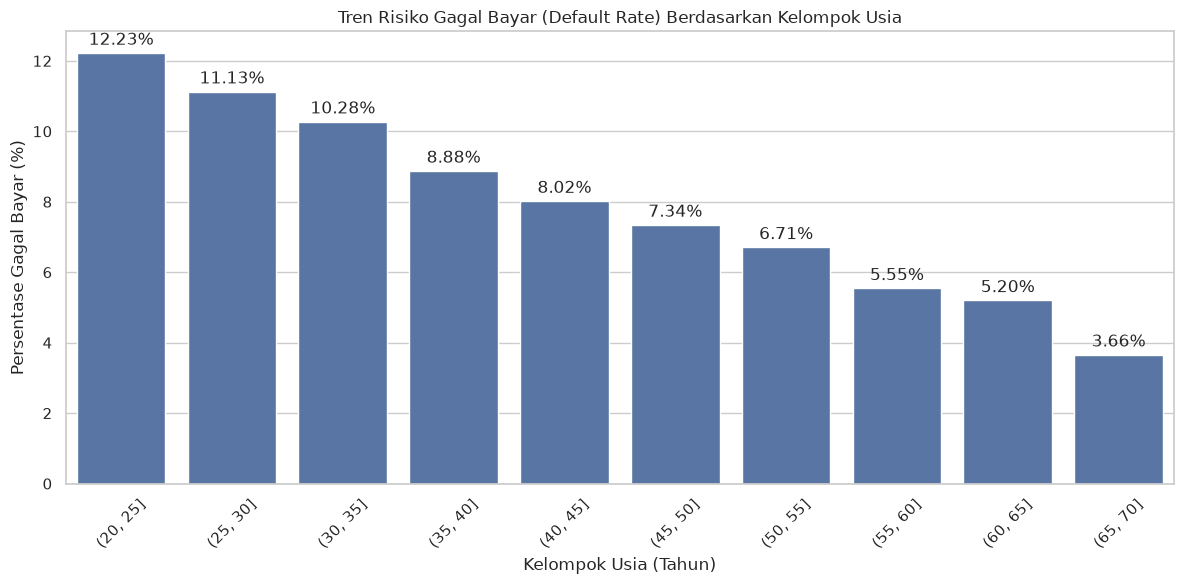

In [13]:
# Default Rate by Age Bin
plt.figure(figsize=(12, 6))

age_bins = pd.cut(eda_df['AGE'], bins=np.arange(20, 75, 5))
age_groups = eda_df.groupby(age_bins, observed=True)['TARGET'].mean() * 100

ax = sns.barplot(x=age_groups.index.astype(str), y=age_groups.values)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.title('Tren Risiko Gagal Bayar (Default Rate) Berdasarkan Kelompok Usia')
plt.xlabel('Kelompok Usia (Tahun)')
plt.ylabel('Persentase Gagal Bayar (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

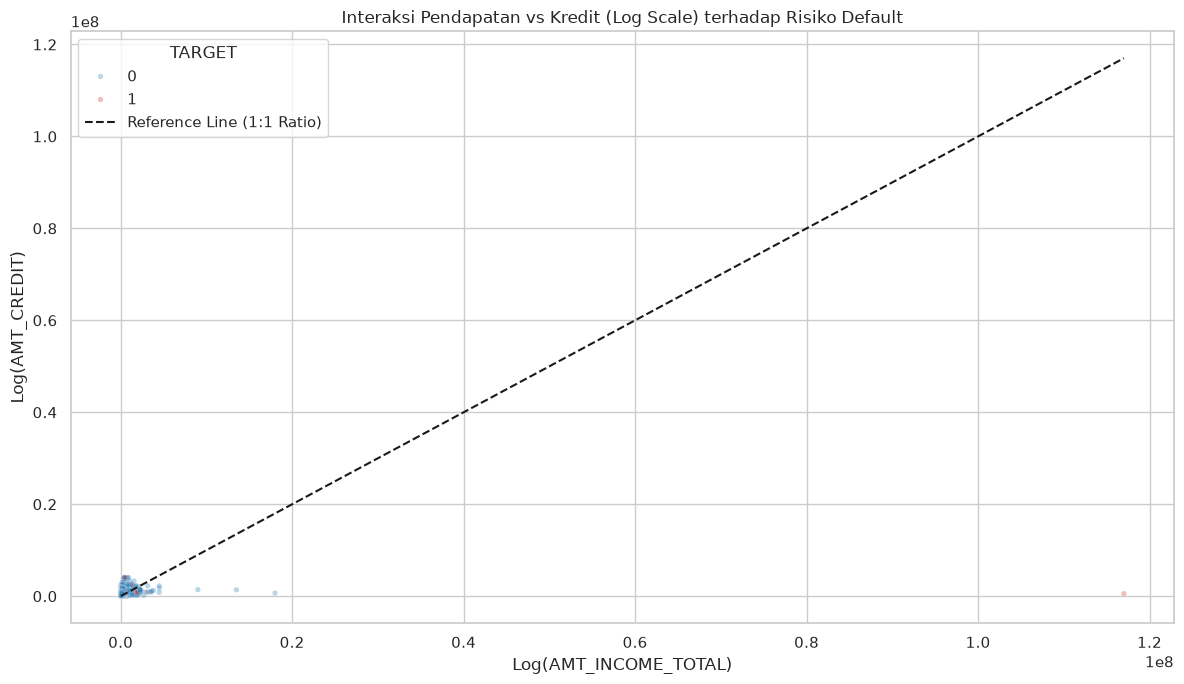

In [14]:
# income vs Credit (Bivariate)
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=eda_df, 
    x='AMT_INCOME_TOTAL', 
    y='AMT_CREDIT', 
    hue='TARGET', 
    palette=['#1f77b4', '#d62728'], 
    alpha=0.3,
    s=15
)

# Garis referensi y=x (Rasio 1:1)
min_val = min(eda_df['AMT_INCOME_TOTAL'].min(), eda_df['AMT_CREDIT'].min())
max_val = max(eda_df['AMT_INCOME_TOTAL'].max(), eda_df['AMT_CREDIT'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, label='Reference Line (1:1 Ratio)')

plt.title('Interaksi Pendapatan vs Kredit (Log Scale) terhadap Risiko Default')
plt.xlabel('Log(AMT_INCOME_TOTAL)')
plt.ylabel('Log(AMT_CREDIT)')
plt.legend(title='TARGET')
plt.tight_layout()
plt.show()

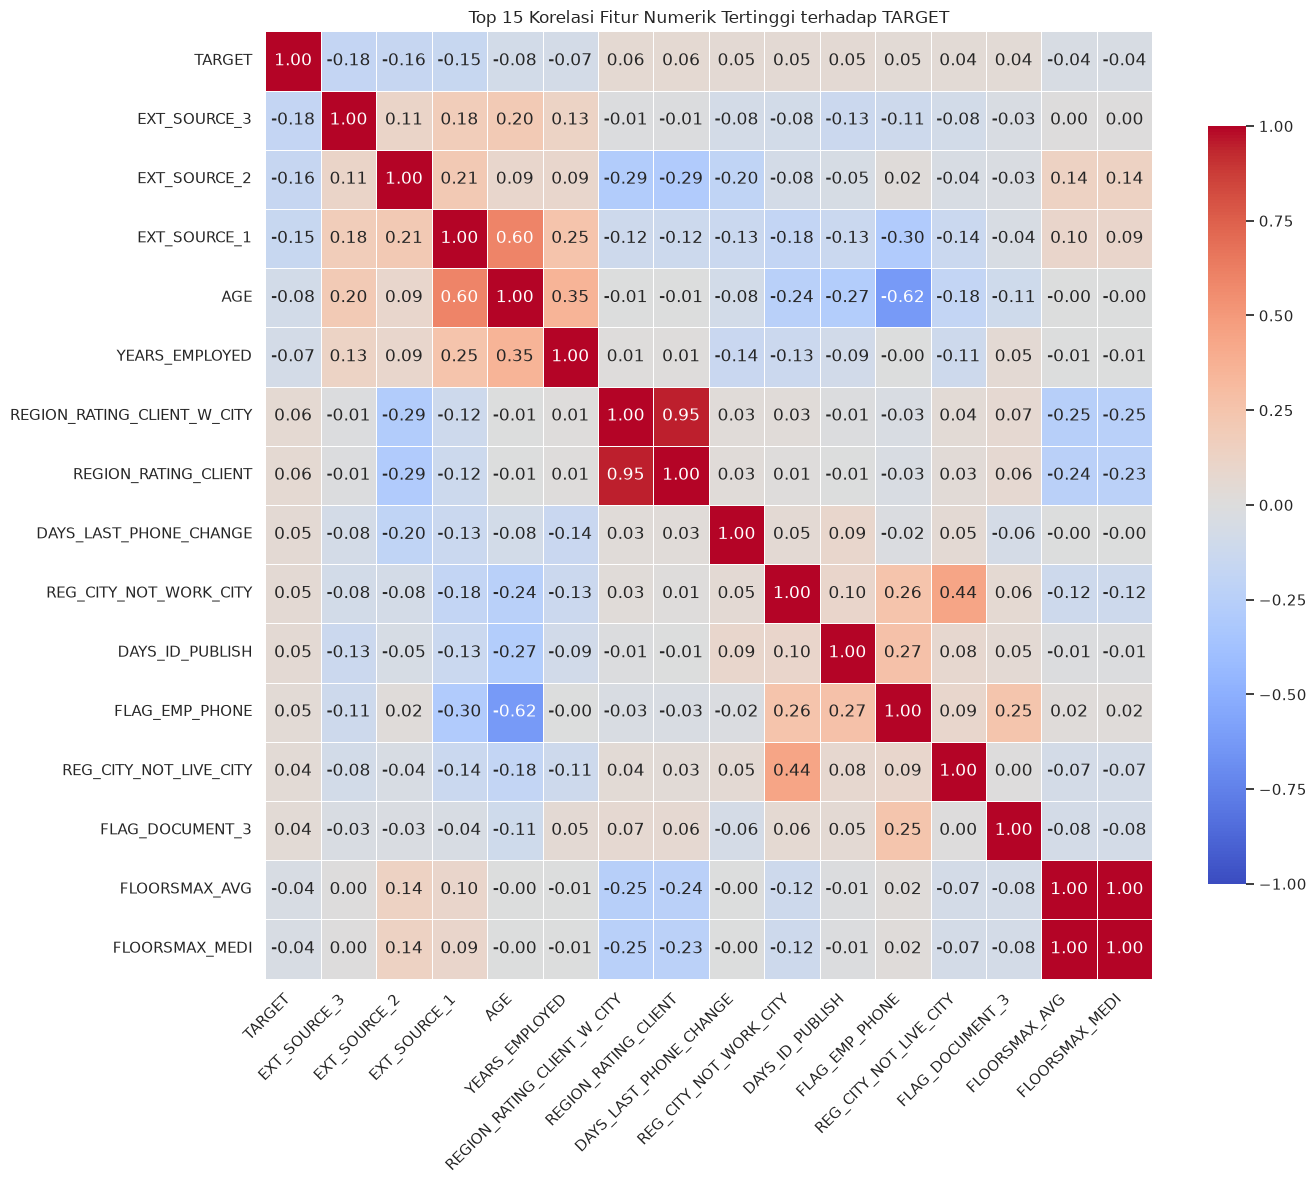

In [15]:
# Top 15 Correlation with TARGET
num_df = eda_df.select_dtypes(include=[np.number])

corr_with_target = num_df.corr()['TARGET'].abs().sort_values(ascending=False)

top_15_features = corr_with_target.head(16).index 
top_15_corr = num_df[top_15_features].corr()

# Plotting Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    top_15_corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Top 15 Korelasi Fitur Numerik Tertinggi terhadap TARGET')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
NUM_COLS = eda_df.select_dtypes(include=np.number).columns

Q1 = eda_df[NUM_COLS].quantile(0.25)
Q3 = eda_df[NUM_COLS].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
is_outlier = (eda_df[NUM_COLS] < lower_bound) | (eda_df[NUM_COLS] > upper_bound)

outliers = is_outlier.sum(axis=0)
pct_cols = (outliers / len(eda_df)) * 100
skew_cols = eda_df[NUM_COLS].skew()

outlier_summary = pd.DataFrame({
    'Jumlah Outlier': outliers,
    'Persentase (%)': pct_cols.round(2),
    'Skewnes': skew_cols.round(2) 
})
print(outlier_summary.nlargest(25, 'Jumlah Outlier'))

                             Jumlah Outlier  Persentase (%)  Skewnes
REGION_RATING_CLIENT                  56344           26.18     0.09
REGION_RATING_CLIENT_W_CITY           54626           25.38     0.06
REG_CITY_NOT_WORK_CITY                49674           23.08     1.28
FLAG_WORK_PHONE                       42947           19.95     1.50
FLAG_EMP_PHONE                        38731           17.99    -1.67
LIVE_CITY_NOT_WORK_CITY               38714           17.99     1.67
AMT_REQ_CREDIT_BUREAU_QRT             35407           16.45   149.95
AMT_REQ_CREDIT_BUREAU_MON             30589           14.21     7.87
DEF_30_CNT_SOCIAL_CIRCLE              24751           11.50     3.86
FLAG_DOCUMENT_6                       18913            8.79     2.91
DEF_60_CNT_SOCIAL_CIRCLE              18127            8.42     4.44
FLAG_DOCUMENT_8                       17480            8.12     3.07
TARGET                                17377            8.07     3.08
REG_CITY_NOT_LIVE_CITY            

### Data Preprocessing & Feature Engineering

In [17]:
NUM_COLS = X_train.select_dtypes(include=np.number).columns
CAT_COLS = X_train.select_dtypes(include=['object']).columns

TRAIN_MEDIAN = X_train[NUM_COLS].median()
TRAIN_MODE = X_train[CAT_COLS].mode().iloc[0]

for df in [X_train, X_val, X_test]:
    df[NUM_COLS] = df[NUM_COLS].fillna(TRAIN_MEDIAN)
    df[CAT_COLS] = df[CAT_COLS].fillna(TRAIN_MODE)

In [18]:
for df in [X_train, X_val, X_test]:
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['CREDIT_TERM'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

for df in [X_train, X_val, X_test]:
    ratio_cols = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM']
    df[ratio_cols] = df[ratio_cols].replace([np.inf, -np.inf], np.nan)

FINANCIAL_COLS = ['AMT_GOODS_PRICE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL']
for df in [X_train, X_val, X_test]:
    for col in FINANCIAL_COLS:
        if col in df.columns:
            df[col] = np.log1p(df[col])

COUNT_COLS = [
    'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]
for col in COUNT_COLS:
    if col in X_train.columns:
        bound = X_train[col].quantile(0.99)
        for df in [X_train, X_val, X_test]:
            df[col] = np.where(df[col] > bound, bound, df[col])

for df in [X_train, X_val, X_test]:
    if 'CNT_CHILDREN' in df.columns:
        df['CNT_CHILDREN'] = np.minimum(df['CNT_CHILDREN'], 5)
    if 'CNT_FAM_MEMBERS' in df.columns:
        df['CNT_FAM_MEMBERS'] = np.minimum(df['CNT_FAM_MEMBERS'], 7)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [20]:
print('Shape final dataset:')
print(f'X_train: {X_train_processed.shape}')
print(f'X_val: {X_val_processed.shape}')
print(f'X_test: {X_test_processed.shape}')

Shape final dataset:
X_train: (215254, 226)
X_val: (46126, 226)
X_test: (46127, 226)


### Model Selection

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

models = {
    'Logistic Regression (Baseline)': lr,
    'Random Forest Classifier': rf
}

print('Model yang akan diuji:')
for name in models:
    print(f'- {name}')

Model yang akan diuji:
- Logistic Regression (Baseline)
- Random Forest Classifier


### Model Training

In [22]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    fbeta_score, precision_recall_curve
)

baseline_results = []

for name, model in models.items():
    print(f'\nMelatih: {name}')

    model.fit(X_train_processed, y_train)
    
    y_val_proba = model.predict_proba(X_val_processed)[:, 1]
    y_val_pred = model.predict(X_val_processed)
    
    roc_auc = roc_auc_score(y_val, y_val_proba)
    pr_auc = average_precision_score(y_val, y_val_proba)
    
    print(f'ROC-AUC (Validation): {roc_auc:.4f}')
    print(f'PR-AUC  (Validation): {pr_auc:.4f}')
    print('\nClassification Report (threshold default 0.5):')
    print(classification_report(y_val, y_val_pred, digits=4))
    
    baseline_results.append({
        'Model': name,
        'ROC-AUC (Val)': roc_auc,
        'PR-AUC (Val)': pr_auc
    })

baseline_summary = pd.DataFrame(baseline_results).sort_values(by='PR-AUC (Val)', ascending=False)
print('\nRingkasan Perbandingan Model Baseline (Validation Set):')
display(baseline_summary)


Melatih: Logistic Regression (Baseline)
ROC-AUC (Validation): 0.7556
PR-AUC  (Validation): 0.2316

Classification Report (threshold default 0.5):
              precision    recall  f1-score   support

           0     0.9617    0.6943    0.8064     42402
           1     0.1644    0.6850    0.2652      3724

    accuracy                         0.6936     46126
   macro avg     0.5631    0.6897    0.5358     46126
weighted avg     0.8973    0.6936    0.7627     46126


Melatih: Random Forest Classifier
ROC-AUC (Validation): 0.7450
PR-AUC  (Validation): 0.2148

Classification Report (threshold default 0.5):
              precision    recall  f1-score   support

           0     0.9223    0.9938    0.9567     42402
           1     0.4009    0.0473    0.0846      3724

    accuracy                         0.9174     46126
   macro avg     0.6616    0.5205    0.5206     46126
weighted avg     0.8802    0.9174    0.8863     46126


Ringkasan Perbandingan Model Baseline (Validation Set):


,Model,ROC-AUC (Val),PR-AUC (Val)
0,Logistic Regression (Baseline),0.755637,0.231640
1,Random Forest Classifier,0.745031,0.214842


### Model Evaluation & Tuning

In [23]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [6, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    scoring='average_precision',
    cv=cv_strategy,                
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_processed, y_train)

print('Best Params:', rf_search.best_params_)
print(f'Best CV PR-AUC (Train): {rf_search.best_score_:.4f}')

best_model = rf_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
Best CV PR-AUC (Train): 0.2189


In [24]:
# Pencegahan overfitting/underfitting
y_train_proba = best_model.predict_proba(X_train_processed)[:, 1]
y_val_proba = best_model.predict_proba(X_val_processed)[:, 1]

train_pr_auc = average_precision_score(y_train, y_train_proba)
val_pr_auc = average_precision_score(y_val, y_val_proba)
gap = train_pr_auc - val_pr_auc

print(f'PR-AUC Train      : {train_pr_auc:.4f}')
print(f'PR-AUC Validation : {val_pr_auc:.4f}')
print(f'Gap (Train-Val)   : {gap:.4f}')

if gap > 0.05:
    print('Gap cukup besar, indikasi overfitting.')
else:
    print('Gap wajar, model tidak overfitting.')

PR-AUC Train      : 0.9999
PR-AUC Validation : 0.2275
Gap (Train-Val)   : 0.7723
Gap cukup besar, indikasi overfitting.


In [25]:
# hreshold Optimization
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)

f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-10)
f2_scores = f2_scores[:-1]

best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

print(f'Threshold optimal (F2-score maksimal): {best_threshold:.4f}')
print(f'F2-score pada threshold ini (Validation): {f2_scores[best_idx]:.4f}')
print(f'Precision: {precisions[best_idx]:.4f} | Recall: {recalls[best_idx]:.4f}')

Threshold optimal (F2-score maksimal): 0.2942
F2-score pada threshold ini (Validation): 0.4180
Precision: 0.1633 | Recall: 0.6853


In [26]:
# Evaluasi Performa FINAL
y_test_proba = best_model.predict_proba(X_test_processed)[:, 1]
y_test_pred_final = (y_test_proba >= best_threshold).astype(int)

test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)
test_f2 = fbeta_score(y_test, y_test_pred_final, beta=2)

print(f'\nEVALUASI FINAL - TEST SET ')
print(f'ROC-AUC : {test_roc_auc:.4f}')
print(f'PR-AUC  : {test_pr_auc:.4f}')
print(f'F2-score: {test_f2:.4f}')
print('\nClassification Report (Test Set, threshold optimal):')
print(classification_report(y_test, y_test_pred_final, digits=4))
print('\nConfusion Matrix (Test Set):')
print(confusion_matrix(y_test, y_test_pred_final))


EVALUASI FINAL - TEST SET 
ROC-AUC : 0.7541
PR-AUC  : 0.2308
F2-score: 0.4212

Classification Report (Test Set, threshold optimal):
              precision    recall  f1-score   support

           0     0.9621    0.6929    0.8057     42403
           1     0.1647    0.6896    0.2659      3724

    accuracy                         0.6927     46127
   macro avg     0.5634    0.6913    0.5358     46127
weighted avg     0.8978    0.6927    0.7621     46127


Confusion Matrix (Test Set):
[[29383 13020]
 [ 1156  2568]]


In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_final).ravel()

approval_rate = (tn + fn) / len(y_test)
npl_baseline = y_test.mean()
npl_after_model = fn / (tn + fn)

print(f'\nDampak Bisnis pada Threshold Optimal:')
print(f'Approval Rate (persetujuan)   : {approval_rate:.2%}')
print(f'NPL rate tanpa model (baseline): {npl_baseline:.2%}')
print(f'NPL rate setelah filtering model: {npl_after_model:.2%}')
print(f'Recall (defaulter tertangkap)  : {tp / (tp + fn):.2%}')


Dampak Bisnis pada Threshold Optimal:
Approval Rate (persetujuan)   : 66.21%
NPL rate tanpa model (baseline): 8.07%
NPL rate setelah filtering model: 3.79%
Recall (defaulter tertangkap)  : 68.96%


### Model Deployment